In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("sales_train_evaluation.csv")

In [4]:
df.head(5)

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,4,0,0,0,0,3,3,0,1
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,1,2,1,1,0,0,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,2,0,0,0,2,3,0,1
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,1,0,4,0,1,3,0,2,6
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,2,1,0,0,2,1,0


In [5]:
df.shape

(30490, 1947)

In [6]:
# Time range d1 to d1941 = 1941 days

In [7]:
# Unique SKUs/store
df.groupby("store_id")["item_id"].nunique()

store_id
CA_1    3049
CA_2    3049
CA_3    3049
CA_4    3049
TX_1    3049
TX_2    3049
TX_3    3049
WI_1    3049
WI_2    3049
WI_3    3049
Name: item_id, dtype: int64

In [8]:
df.loc[:, "d_1":].isnull().sum().any()

np.False_

In [9]:
# The data is daily not weekly

In [10]:
cal = pd.read_csv("calendar.csv")

In [11]:
cal.head(5)

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


In [12]:
cal.shape

(1969, 14)

In [13]:
# Pivoting rows to columns using melt() to have demand of 1941 days in column wise.

id_cols = ["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"]

df_long = df.melt(id_vars = id_cols, var_name = "d", value_name = "demand") 
df_long.shape

(59181090, 8)

In [14]:
df_long.head(5)

,id,item_id,dept_id,cat_id,store_id,state_id,d,demand
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0


In [15]:
df_merged = df_long.merge(cal[["d", "date", "wm_yr_wk", "event_name_1", "event_type_1", "event_name_2", "event_type_2"]], on = 'd', how = 'left')
df_merged.head(5)

,id,item_id,dept_id,cat_id,store_id,state_id,d,demand,date,wm_yr_wk,event_name_1,event_type_1,event_name_2,event_type_2
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,NaN,NaN,NaN,NaN
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,NaN,NaN,NaN,NaN
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,NaN,NaN,NaN,NaN
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,NaN,NaN,NaN,NaN
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,NaN,NaN,NaN,NaN


In [16]:
df_merged.shape

(59181090, 14)

In [17]:
sell_prices = pd.read_csv("sell_prices.csv")
sell_prices.head(5)

,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26


In [18]:
sell_prices.shape

(6841121, 4)

In [19]:
sell_prices.isnull().sum()

store_id      0
item_id       0
wm_yr_wk      0
sell_price    0
dtype: int64

In [20]:
# Checking the total demand and zero-demand % per store
store_summary = df_merged.groupby(['state_id','store_id']).agg(
    total_demand    = ('demand', 'sum'),
    zero_demand_pct = ('demand', lambda x: (x == 0).mean() * 100)
).reset_index().sort_values(['state_id', 'total_demand'], ascending=[True, False])

print(store_summary)

  state_id store_id  total_demand  zero_demand_pct
2       CA     CA_3      11363540        59.399768
0       CA     CA_1       7832248        63.759049
1       CA     CA_2       5818395        68.810291
3       CA     CA_4       4182534        71.999519
5       TX     TX_2       7329642        66.314172
6       TX     TX_3       6205940        69.715073
4       TX     TX_1       5692823        70.714074
8       WI     WI_2       6697988        70.480047
9       WI     WI_3       6542557        70.031610
7       WI     WI_1       5261506        68.754056


In [21]:
# Creating a subset of df_merged with just the top stores from each state "stores_to_keep" for ML training.

stores_to_keep = ['CA_3', 'TX_2', 'WI_3']
df = df_merged[df_merged['store_id'].isin(stores_to_keep)].copy()

print(df.shape)
print(df['store_id'].value_counts())

(17754327, 14)
store_id
CA_3    5918109
TX_2    5918109
WI_3    5918109
Name: count, dtype: int64


In [22]:
# Converting 'date' col to datetime data type 

df['date'] = pd.to_datetime(df['date'])

In [23]:
df.head(5)

,id,item_id,dept_id,cat_id,store_id,state_id,d,demand,date,wm_yr_wk,event_name_1,event_type_1,event_name_2,event_type_2
6098,HOBBIES_1_001_CA_3_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_3,CA,d_1,0,2011-01-29,11101,NaN,NaN,NaN,NaN
6099,HOBBIES_1_002_CA_3_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_3,CA,d_1,0,2011-01-29,11101,NaN,NaN,NaN,NaN
6100,HOBBIES_1_003_CA_3_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_3,CA,d_1,0,2011-01-29,11101,NaN,NaN,NaN,NaN
6101,HOBBIES_1_004_CA_3_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_3,CA,d_1,0,2011-01-29,11101,NaN,NaN,NaN,NaN
6102,HOBBIES_1_005_CA_3_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_3,CA,d_1,0,2011-01-29,11101,NaN,NaN,NaN,NaN


In [34]:
df['has_sporting_event']  = ((df['event_type_1'] == 'Sporting')  | (df['event_type_2'] == 'Sporting')).astype(int)
df['has_national_event']  = ((df['event_type_1'] == 'National')  | (df['event_type_2'] == 'National')).astype(int)
df['has_religious_event'] = ((df['event_type_1'] == 'Religious') | (df['event_type_2'] == 'Religious')).astype(int)
df['has_cultural_event']  = ((df['event_type_1'] == 'Cultural')  | (df['event_type_2'] == 'Cultural')).astype(int)
df['event_count']         = (df['event_name_1'].notna().astype(int) + df['event_name_2'].notna().astype(int))

In [35]:
df_weekly = df.groupby(
    ['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'wm_yr_wk'],
    as_index=False
).agg(
    weekly_demand        = ('demand', 'sum'),
    date                 = ('date', 'first'),
    sporting_event_days   = ('has_sporting_event', 'sum'),
    national_event_days  = ('has_national_event', 'sum'),
    religious_event_days  = ('has_religious_event','sum'),
    cultural_event_days   = ('has_cultural_event', 'sum'),
    weekly_event_count   = ('event_count', 'sum'),
)

df_weekly = df_weekly.sort_values(
    ['item_id', 'store_id', 'wm_yr_wk']
).reset_index(drop=True)

In [36]:
df_weekly.head(5)
print(df_weekly.shape)

(2542866, 13)


In [37]:
df_weekly = df_weekly.merge(
    sell_prices[['store_id', 'item_id', 'wm_yr_wk', 'sell_price']],
    on=['store_id', 'item_id', 'wm_yr_wk'],
    how='left'
)

In [38]:
# After merging with sell_prices data

df_weekly.head(5)

,item_id,dept_id,cat_id,store_id,state_id,wm_yr_wk,weekly_demand,date,sporting_event_days,national_event_days,religious_event_days,cultural_event_days,weekly_event_count,sell_price
0,FOODS_1_001,FOODS_1,FOODS,CA_3,CA,11101,8,2011-01-29,0,0,0,0,0,2.0
1,FOODS_1_001,FOODS_1,FOODS,CA_3,CA,11102,9,2011-02-05,1,0,0,0,1,2.0
2,FOODS_1_001,FOODS_1,FOODS,CA_3,CA,11103,17,2011-02-12,0,0,0,1,1,2.0
3,FOODS_1_001,FOODS_1,FOODS,CA_3,CA,11104,6,2011-02-19,0,1,0,0,1,2.0
4,FOODS_1_001,FOODS_1,FOODS,CA_3,CA,11105,18,2011-02-26,0,0,0,0,0,2.0


In [39]:
print(df_weekly.shape)
print(df_weekly['sell_price'].isnull().sum())

(2542866, 14)
488156


In [40]:
weeks_per_sku = df_weekly.groupby(['item_id', 'store_id'])['wm_yr_wk'].count()
print(weeks_per_sku.describe())

sample = df_weekly[
    (df_weekly['item_id'] == 'HOBBIES_1_001') &
    (df_weekly['store_id'] == 'CA_3')
]
print(f"Total weeks for this item-store: {len(sample)}")
#print(sample.head(10))

count    9147.0
mean      278.0
std         0.0
min       278.0
25%       278.0
50%       278.0
75%       278.0
max       278.0
Name: wm_yr_wk, dtype: float64
Total weeks for this item-store: 278


In [44]:
# Which categories have the most missing prices?
null_prices = df_weekly[df_weekly['sell_price'].isnull()]
print(null_prices.groupby('cat_id')['sell_price'].count())
print(null_prices.groupby('cat_id').size())

cat_id
FOODS        0
HOBBIES      0
HOUSEHOLD    0
Name: sell_price, dtype: int64
cat_id
FOODS        225805
HOBBIES       89895
HOUSEHOLD    172456
dtype: int64


In [45]:
# Are nulls concentrated at the start or end of the time period?
print(null_prices['wm_yr_wk'].describe())

count    488156.000000
mean      11208.525207
std          92.386608
min       11101.000000
25%       11127.000000
50%       11207.000000
75%       11250.000000
max       11602.000000
Name: wm_yr_wk, dtype: float64


In [46]:
# Sort first to ensure correct order before filling
df_weekly = df_weekly.sort_values(['item_id', 'store_id', 'wm_yr_wk'])

# Backfill first (fills early nulls with first known price)
# Then forward fill (handles any remaining mid-series gaps)
df_weekly['sell_price'] = df_weekly.groupby(
    ['item_id', 'store_id']
)['sell_price'].transform(lambda x: x.bfill().ffill())

# Verify nulls are gone
print(df_weekly['sell_price'].isnull().sum())

0


## Simulating Lead Times ##
### Since actual supplier lead time data is not available in the dataset ###

In [266]:
import numpy as np

def simulate_lead_time(df, seed=42):
    rng = np.random.default_rng(seed)
    
    profiles = {
        'FOODS':     {'mean': 3,  'std': 1.0, 'max': 6},
        'HOUSEHOLD': {'mean': 7,  'std': 2.0, 'max': 12},
        'HOBBIES':   {'mean': 10, 'std': 3.0, 'max': 17},
    }
    
    lead_times = np.zeros(len(df))
    
    for cat, params in profiles.items():
        mask = df['cat_id'] == cat
        count = mask.sum()
        lt = rng.normal(loc=params['mean'], scale=params['std'], size=count)
        lt = np.clip(lt, 1, params['max'])
        lead_times[mask] = lt
    
    return lead_times

df_weekly['lead_time_days']  = simulate_lead_time(df_weekly)
df_weekly['lead_time_weeks'] = df_weekly['lead_time_days'] / 7

In [267]:
# Checking for zeros or negatives
print(df_weekly['lead_time_days'].min())
print(df_weekly['lead_time_weeks'].min())

# Checking if the distributions look realistic per category
print(df_weekly.groupby('cat_id')[['lead_time_days']].agg(['mean','std']))

1.0
0.14285714285714285
          lead_time_days          
                    mean       std
cat_id                            
FOODS           3.008500  0.978586
HOBBIES         9.990254  2.970656
HOUSEHOLD       6.998863  1.985648


In [268]:
df_weekly.head(3)

,item_id,dept_id,cat_id,store_id,state_id,wm_yr_wk,weekly_demand,date,sporting_event_days,national_event_days,...,cat_id_enc,dept_id_enc,store_id_enc,state_id_enc,target_demand_std,target_lt_std,demand_lag1,demand_lag2,price_change,demand_acceleration
0,FOODS_1_001,FOODS_1,FOODS,CA_3,CA,11114,9,2011-04-30,0,0,...,0,0,0,0,10.424331,0.109772,14.0,18.0,0.0,-4.0
1,FOODS_1_001,FOODS_1,FOODS,CA_3,CA,11115,22,2011-05-07,0,0,...,0,0,0,0,12.038134,0.129992,9.0,14.0,0.0,-5.0
2,FOODS_1_001,FOODS_1,FOODS,CA_3,CA,11116,8,2011-05-14,0,0,...,0,0,0,0,10.996211,0.111129,22.0,9.0,0.0,13.0


#### Rolling Statistics for "Demand" ####

In [112]:
# Feature Engineering. Generating Rolling demand stats for 4/8/13 weeks.

for w in [4, 8, 13]:
    df_weekly[f'demand_mean_{w}w'] = df_weekly.groupby(
        ['item_id', 'store_id'])['weekly_demand'].transform(
        lambda x: x.shift(1).rolling(w, min_periods=w).mean())
    
    df_weekly[f'demand_std_{w}w'] = df_weekly.groupby(
        ['item_id', 'store_id'])['weekly_demand'].transform(
        lambda x: x.shift(1).rolling(w, min_periods=w).std())
    
    df_weekly[f'demand_cv_{w}w'] = (
        df_weekly[f'demand_std_{w}w'] / 
        (df_weekly[f'demand_mean_{w}w'] + 1e-9)
    )

#### Rolling Statistics for "Lead Time" ####

In [269]:
# Feature Engineering. Generating Rolling lead time stats for 4/8/13 weeks.

for w in [4, 8, 13]:
    df_weekly[f'lt_mean_{w}w'] = df_weekly.groupby(
        ['item_id', 'store_id'])['lead_time_weeks'].transform(
        lambda x: x.shift(1).rolling(w, min_periods=w).mean())
    
    df_weekly[f'lt_std_{w}w'] = df_weekly.groupby(
        ['item_id', 'store_id'])['lead_time_weeks'].transform(
        lambda x: x.shift(1).rolling(w, min_periods=w).std())
    
    df_weekly[f'lt_cv_{w}w'] = (
        df_weekly[f'lt_std_{w}w'] / 
        (df_weekly[f'lt_mean_{w}w'] + 1e-9)
    )

In [114]:
# creating lag features. Demand of prev and a week before that. 

df_weekly['demand_lag1'] = df_weekly.groupby(
    ['item_id', 'store_id'])['weekly_demand'].transform(
    lambda x: x.shift(1))

df_weekly['demand_lag2'] = df_weekly.groupby(
    ['item_id', 'store_id'])['weekly_demand'].transform(
    lambda x: x.shift(2))

#### Calender features ####

In [115]:
df_weekly['week_of_year'] = df_weekly['date'].dt.isocalendar().week.astype(int)
df_weekly['month'] = df_weekly['date'].dt.month
df_weekly['quarter'] = df_weekly['date'].dt.quarter

In [116]:
df_weekly.columns

Index(['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'wm_yr_wk',
       'weekly_demand', 'date', 'sporting_event_days', 'national_event_days',
       'religious_event_days', 'cultural_event_days', 'weekly_event_count',
       'sell_price', 'lead_time_days', 'lead_time_weeks', 'demand_mean_4w',
       'demand_std_4w', 'demand_cv_4w', 'demand_mean_8w', 'demand_std_8w',
       'demand_cv_8w', 'demand_mean_13w', 'demand_std_13w', 'demand_cv_13w',
       'lt_mean_4w', 'lt_std_4w', 'lt_cv_4w', 'lt_mean_8w', 'lt_std_8w',
       'lt_cv_8w', 'lt_mean_13w', 'lt_std_13w', 'lt_cv_13w', 'week_of_year',
       'month', 'quarter', 'cat_id_enc', 'dept_id_enc', 'store_id_enc',
       'state_id_enc', 'target_demand_std', 'target_lt_std', 'demand_lag1',
       'demand_lag2'],
      dtype='object')

In [75]:
df_weekly.head(30)

,item_id,dept_id,cat_id,store_id,state_id,wm_yr_wk,weekly_demand,date,sporting_event_days,national_event_days,...,lt_cv_4w,lt_mean_8w,lt_std_8w,lt_cv_8w,lt_mean_13w,lt_std_13w,lt_cv_13w,week_of_year,month,quarter
0,FOODS_1_001,FOODS_1,FOODS,CA_3,CA,11101,8,2011-01-29,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,1,1
1,FOODS_1_001,FOODS_1,FOODS,CA_3,CA,11102,9,2011-02-05,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,2,1
2,FOODS_1_001,FOODS_1,FOODS,CA_3,CA,11103,17,2011-02-12,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6,2,1
3,FOODS_1_001,FOODS_1,FOODS,CA_3,CA,11104,6,2011-02-19,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7,2,1
4,FOODS_1_001,FOODS_1,FOODS,CA_3,CA,11105,18,2011-02-26,0,0,...,0.275797,NaN,NaN,NaN,NaN,NaN,NaN,8,2,1
5,FOODS_1_001,FOODS_1,FOODS,CA_3,CA,11106,19,2011-03-05,0,0,...,0.524851,NaN,NaN,NaN,NaN,NaN,NaN,9,3,1
6,FOODS_1_001,FOODS_1,FOODS,CA_3,CA,11107,6,2011-03-12,0,0,...,0.557099,NaN,NaN,NaN,NaN,NaN,NaN,10,3,1
7,FOODS_1_001,FOODS_1,FOODS,CA_3,CA,11108,8,2011-03-19,0,0,...,0.537049,NaN,NaN,NaN,NaN,NaN,NaN,11,3,1
8,FOODS_1_001,FOODS_1,FOODS,CA_3,CA,11109,8,2011-03-26,0,0,...,0.439880,0.384181,0.147559,0.384088,NaN,NaN,NaN,12,3,1
9,FOODS_1_001,FOODS_1,FOODS,CA_3,CA,11110,19,2011-04-02,0,0,...,0.245511,0.378440,0.144512,0.381862,NaN,NaN,NaN,13,4,2


### Encoding categorical variables ###

In [117]:
from sklearn.preprocessing import LabelEncoder

for col in ['cat_id', 'dept_id', 'store_id', 'state_id']:
    le = LabelEncoder()
    df_weekly[f'{col}_enc'] = le.fit_transform(df_weekly[col])

In [85]:
df_weekly.sample(15)

,item_id,dept_id,cat_id,store_id,state_id,wm_yr_wk,weekly_demand,date,sporting_event_days,national_event_days,...,lt_mean_13w,lt_std_13w,lt_cv_13w,week_of_year,month,quarter,cat_id_enc,dept_id_enc,store_id_enc,state_id_enc
244962,FOODS_2_078,FOODS_2,FOODS,WI_3,WI,11145,0,2011-12-03,0,0,...,0.420505,0.123546,0.293804,48,12,4,0,1,2,2
1926565,HOUSEHOLD_1_315,HOUSEHOLD_1,HOUSEHOLD,CA_3,CA,11126,0,2011-07-23,0,0,...,0.922528,0.362342,0.392771,29,7,3,2,5,0,0
1684982,HOUSEHOLD_1_019,HOUSEHOLD_1,HOUSEHOLD,TX_2,TX,11125,0,2011-07-16,0,0,...,1.049955,0.380779,0.362663,28,7,3,2,5,1,1
2134534,HOUSEHOLD_2_026,HOUSEHOLD_2,HOUSEHOLD,TX_2,TX,11151,0,2012-01-14,0,1,...,0.920108,0.381753,0.414901,2,1,1,2,6,1,1
582831,FOODS_3_086,FOODS_3,FOODS,WI_3,WI,11340,24,2013-10-26,0,0,...,0.410138,0.107627,0.262417,43,10,4,0,2,2,2
1072785,FOODS_3_674,FOODS_3,FOODS,CA_3,CA,11601,27,2016-01-30,0,0,...,0.478672,0.108216,0.226076,4,1,1,0,2,0,0
935989,FOODS_3_510,FOODS_3,FOODS,CA_3,CA,11533,1,2015-09-12,0,0,...,0.388850,0.119440,0.307161,37,9,3,0,2,0,0
299656,FOODS_2_145,FOODS_2,FOODS,CA_3,CA,11542,32,2015-11-14,0,0,...,0.451893,0.164359,0.363711,46,11,4,0,1,0,0
362506,FOODS_2_220,FOODS_2,FOODS,TX_2,TX,11612,3,2016-04-16,0,0,...,0.430699,0.147692,0.342913,15,4,2,0,1,1,1
2539587,HOUSEHOLD_2_513,HOUSEHOLD_2,HOUSEHOLD,CA_3,CA,11206,0,2012-03-03,0,0,...,0.875816,0.399060,0.455643,9,3,1,2,6,0,0


In [271]:
# Creating target variables

df_weekly['target_demand_std'] = df_weekly.groupby(
    ['item_id', 'store_id'])['weekly_demand'].transform(
    lambda x: x.shift(-4).rolling(4, min_periods=4).std())

df_weekly['target_lt_std'] = df_weekly.groupby(
    ['item_id', 'store_id'])['lead_time_weeks'].transform(
    lambda x: x.shift(-4).rolling(4, min_periods=4).std())

In [140]:
df_weekly.head(5)

,item_id,dept_id,cat_id,store_id,state_id,wm_yr_wk,weekly_demand,date,sporting_event_days,national_event_days,...,month,quarter,cat_id_enc,dept_id_enc,store_id_enc,state_id_enc,target_demand_std,target_lt_std,demand_lag1,demand_lag2
0,FOODS_1_001,FOODS_1,FOODS,CA_3,CA,11101,8,2011-01-29,0,0,...,1,1,0,0,0,0,NaN,NaN,NaN,NaN
1,FOODS_1_001,FOODS_1,FOODS,CA_3,CA,11102,9,2011-02-05,1,0,...,2,1,0,0,0,0,NaN,NaN,8.0,NaN
2,FOODS_1_001,FOODS_1,FOODS,CA_3,CA,11103,17,2011-02-12,0,0,...,2,1,0,0,0,0,NaN,NaN,9.0,8.0
3,FOODS_1_001,FOODS_1,FOODS,CA_3,CA,11104,6,2011-02-19,0,1,...,2,1,0,0,0,0,6.701990,0.134452,17.0,9.0
4,FOODS_1_001,FOODS_1,FOODS,CA_3,CA,11105,18,2011-02-26,0,0,...,2,1,0,0,0,0,5.909033,0.092002,6.0,17.0


In [272]:
# Creating new features: 
    # Price_change_rate - 
    # The change in price week over week is more informative than the absolute price (sell_price).
    # A sudden price drop signals a promotion which drives demand spikes.

df_weekly['price_change'] = df_weekly.groupby(
    ['item_id', 'store_id'])['sell_price'].transform(
    lambda x: x.pct_change())

    # Demand_acceleration - The difference between demand_lag1 and demand_lag2 tells the model whether demand is accelerating or decelerating right now,
    # which is more informative than either lag alone.

df_weekly['demand_acceleration'] = df_weekly['demand_lag1'] - df_weekly['demand_lag2']

In [273]:
# Dropping NaNs

# reset_index() is used to create a new index for the new DF after dropping NaN rows instead of using the old index. (drop=True) prevents the pandas
    # from trying to save the old broken index as a separate index column, which is unecessary. 

df_weekly = df_weekly.dropna().reset_index(drop=True)
print(df_weekly.shape)
print(df_weekly.isnull().sum().sum())

(2231868, 47)
0


In [151]:
print(df_weekly.columns.tolist())

['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'wm_yr_wk', 'weekly_demand', 'date', 'sporting_event_days', 'national_event_days', 'religious_event_days', 'cultural_event_days', 'weekly_event_count', 'sell_price', 'lead_time_days', 'lead_time_weeks', 'demand_mean_4w', 'demand_std_4w', 'demand_cv_4w', 'demand_mean_8w', 'demand_std_8w', 'demand_cv_8w', 'demand_mean_13w', 'demand_std_13w', 'demand_cv_13w', 'lt_mean_4w', 'lt_std_4w', 'lt_cv_4w', 'lt_mean_8w', 'lt_std_8w', 'lt_cv_8w', 'lt_mean_13w', 'lt_std_13w', 'lt_cv_13w', 'week_of_year', 'month', 'quarter', 'cat_id_enc', 'dept_id_enc', 'store_id_enc', 'state_id_enc', 'target_demand_std', 'target_lt_std', 'demand_lag1', 'demand_lag2', 'price_change', 'demand_acceleration']


In [153]:
df_weekly.head(3)

,item_id,dept_id,cat_id,store_id,state_id,wm_yr_wk,weekly_demand,date,sporting_event_days,national_event_days,...,cat_id_enc,dept_id_enc,store_id_enc,state_id_enc,target_demand_std,target_lt_std,demand_lag1,demand_lag2,price_change,demand_acceleration
0,FOODS_1_001,FOODS_1,FOODS,CA_3,CA,11114,9,2011-04-30,0,0,...,0,0,0,0,10.424331,0.109772,14.0,18.0,0.0,-4.0
1,FOODS_1_001,FOODS_1,FOODS,CA_3,CA,11115,22,2011-05-07,0,0,...,0,0,0,0,12.038134,0.129992,9.0,14.0,0.0,-5.0
2,FOODS_1_001,FOODS_1,FOODS,CA_3,CA,11116,8,2011-05-14,0,0,...,0,0,0,0,10.996211,0.111129,22.0,9.0,0.0,13.0


In [ ]:
# Train/Test split

split_index = int(len(df_model) * 0.80)

train = df_model.iloc[:split_index]
test  = df_model.iloc[split_index:]

X_train = train[feature_cols]
y_train = train['target_demand_std']

X_test = test[feature_cols]
y_test = test['target_demand_std']

print(f"Train size: {len(train)}")
print(f"Test size:  {len(test)}")





# Training the model

from sklearn.ensemble import RandomForestRegressor

model_demand = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

model_demand.fit(X_train, y_train)
print("Training complete.")





from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model_demand.predict(X_test)
y_pred = np.clip(y_pred, 0, None)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

import joblib
joblib.dump(model_demand, 'model_demand_std.pkl')
print("Model saved.")

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.1, s=5, color='steelblue')
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Demand Std')
plt.ylabel('Predicted Demand Std')
plt.title(f'Demand Variability Model — Predicted vs Actual\nR²={r2:.3f}  RMSE={rmse:.3f}')
plt.legend()
plt.tight_layout()
plt.savefig('plot_demand_model_pred_vs_actual.png', dpi=150)
plt.show()

import pandas as pd

importance_df = pd.DataFrame({
    'feature':    feature_cols,
    'importance': model_demand.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(8, 6))
plt.barh(importance_df['feature'], importance_df['importance'], color='steelblue')
plt.gca().invert_yaxis()
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances — Demand Variability Model')
plt.tight_layout()
plt.savefig('plot_demand_model_feature_importance.png', dpi=150)
plt.show()

In [132]:
# Checkpoint 6 — Lead Time Variability Model

X_train_lt = train[feature_cols]
y_train_lt  = train['target_lt_std']

X_test_lt = test[feature_cols]
y_test_lt  = test['target_lt_std']

model_lt = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

model_lt.fit(X_train_lt, y_train_lt)
print("Training complete.")

y_pred_lt = model_lt.predict(X_test_lt)
y_pred_lt = np.clip(y_pred_lt, 0, None)

mae_lt  = mean_absolute_error(y_test_lt, y_pred_lt)
rmse_lt = np.sqrt(mean_squared_error(y_test_lt, y_pred_lt))
r2_lt   = r2_score(y_test_lt, y_pred_lt)

print(f"MAE:  {mae_lt:.4f}")
print(f"RMSE: {rmse_lt:.4f}")
print(f"R²:   {r2_lt:.4f}")

joblib.dump(model_lt, 'model_lt_std.pkl')
print("Model saved.")

Training complete.
MAE:  0.0889
RMSE: 0.1104
R²:   -0.0001
Model saved.


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test_lt, y_pred_lt, alpha=0.1, s=5, color='steelblue')
plt.plot([y_test_lt.min(), y_test_lt.max()], 
         [y_test_lt.min(), y_test_lt.max()], 
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Lead Time Std')
plt.ylabel('Predicted Lead Time Std')
plt.title(f'Lead Time Variability Model — Predicted vs Actual\nR²={r2_lt:.3f}  RMSE={rmse_lt:.3f}')
plt.legend()
plt.tight_layout()
#plt.savefig('plot_lead_time_model_pred_vs_actual.png', dpi=150)
plt.show()

import pandas as pd

importance_df = pd.DataFrame({
    'feature':    feature_cols,
    'importance': model_lt.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(8, 6))
plt.barh(importance_df['feature'], importance_df['importance'], color='steelblue')
plt.gca().invert_yaxis()
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances — Lead Time Variability Model')
plt.tight_layout()
#plt.savefig('plot_lead_time_model_feature_importance.png', dpi=150)
plt.show()



In [202]:
# Creating a df_model from df_weekly excluding the prediction irrelevant columns (general categorical columns that have been hot encoded)

exclude_cols = ['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id',
                'wm_yr_wk', 'date', 'weekly_demand', 'lead_time_days', 'lead_time_weeks']

df_model = df_weekly.drop(columns=exclude_cols)

In [204]:
print(df_model.shape)
print(df_model.columns)

(2387367, 37)
Index(['sporting_event_days', 'national_event_days', 'religious_event_days',
       'cultural_event_days', 'weekly_event_count', 'sell_price',
       'demand_mean_4w', 'demand_std_4w', 'demand_cv_4w', 'demand_mean_8w',
       'demand_std_8w', 'demand_cv_8w', 'demand_mean_13w', 'demand_std_13w',
       'demand_cv_13w', 'lt_mean_4w', 'lt_std_4w', 'lt_cv_4w', 'lt_mean_8w',
       'lt_std_8w', 'lt_cv_8w', 'lt_mean_13w', 'lt_std_13w', 'lt_cv_13w',
       'week_of_year', 'month', 'quarter', 'cat_id_enc', 'dept_id_enc',
       'store_id_enc', 'state_id_enc', 'target_demand_std', 'target_lt_std',
       'demand_lag1', 'demand_lag2', 'price_change', 'demand_acceleration'],
      dtype='object')


In [233]:
# DF for demand model prediction

exclude_lt_features = ['lt_mean_4w', 'lt_std_4w', 'lt_cv_4w', 'lt_mean_8w', 'lt_std_8w', 'lt_cv_8w',
                       'lt_mean_13w', 'lt_std_13w', 'lt_cv_13w', 'target_lt_std']

df_model_demand = df_model.drop(columns=exclude_lt_features) 

demand_cols = list(df_model_demand.columns)
demand_cols.append(demand_cols.pop(demand_cols.index('target_demand_std')))

df_model_demand = df_model_demand[demand_cols]

In [245]:
df_model_demand.shape

(2387367, 27)

In [234]:
df_model_demand.head(3)

,sporting_event_days,national_event_days,religious_event_days,cultural_event_days,weekly_event_count,sell_price,demand_mean_4w,demand_std_4w,demand_cv_4w,demand_mean_8w,...,quarter,cat_id_enc,dept_id_enc,store_id_enc,state_id_enc,demand_lag1,demand_lag2,price_change,demand_acceleration,target_demand_std
0,0,0,0,1,1,2.0,15.25,4.112988,0.269704,12.75,...,2,0,0,0,0,14.0,18.0,0.0,-4.0,10.424331
1,0,0,0,1,1,2.0,12.75,4.112988,0.322587,11.50,...,2,0,0,0,0,9.0,14.0,0.0,-5.0,12.038134
2,0,0,0,0,0,2.0,15.75,5.560276,0.353033,13.50,...,2,0,0,0,0,22.0,9.0,0.0,13.0,10.996211


In [284]:
df_model.to_parquet('df_model_parquet')
df_model_demand.to_parquet('df_model_demand_parquet')

In [243]:
# Train/test split and training the demand prediction model

# Split into X and y first
X = df_model_demand.iloc[:, :-1]
y = df_model_demand.iloc[:, -1]

# Then split by index
split_index = int(len(df_model_demand) * 0.80)

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]


from sklearn.ensemble import RandomForestRegressor

model_demand = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

model_demand.fit(X_train, y_train)
print("Training complete.")

Training complete.


In [244]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model_demand.predict(X_test)
y_pred = np.clip(y_pred, 0, None)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

import joblib
joblib.dump(model_demand, 'model_demand_std.pkl')
print("Model saved.")

MAE:  0.9683
RMSE: 2.9260
R²:   0.4355
Model saved.


In [283]:
abd = ['cat_id', 'store_id', 'date', 'weekly_demand', 'lead_time_days', 'lead_time_weeks', 'lt_mean_4w', 'lt_std_4w', 'lt_cv_4w', 'lt_mean_8w', 'lt_std_8w', 'lt_cv_8w',
                       'lt_mean_13w', 'lt_std_13w', 'lt_cv_13w', 'target_lt_std']

df_weekly[abd].sample(25)

,cat_id,store_id,date,weekly_demand,lead_time_days,lead_time_weeks,lt_mean_4w,lt_std_4w,lt_cv_4w,lt_mean_8w,lt_std_8w,lt_cv_8w,lt_mean_13w,lt_std_13w,lt_cv_13w,target_lt_std
1990399,HOUSEHOLD,CA_3,2013-04-27,15,6.992665,0.998952,1.244427,0.286717,0.230400,1.046707,0.411971,0.393588,0.988130,0.356235,0.360514,0.261717
1037888,FOODS,WI_3,2014-07-26,0,3.549466,0.507067,0.424687,0.070709,0.166498,0.538071,0.165178,0.306982,0.494735,0.158657,0.320690,0.117592
2185402,HOUSEHOLD,TX_2,2014-03-22,6,6.250812,0.892973,0.975666,0.219358,0.224829,0.889372,0.224383,0.252293,0.977711,0.209970,0.214757,0.424957
5931,FOODS,CA_3,2013-01-05,4,5.070399,0.724343,0.436305,0.090866,0.208264,0.438200,0.104605,0.238716,0.420870,0.097231,0.231023,0.138223
312045,FOODS,CA_3,2015-08-29,1,2.449456,0.349922,0.405420,0.168340,0.415224,0.344720,0.177095,0.513737,0.352151,0.155093,0.440416,0.131270
736797,FOODS,TX_2,2014-08-30,1,3.904280,0.557754,0.422224,0.214646,0.508371,0.454686,0.188961,0.415587,0.475285,0.187966,0.395481,0.157677
2122523,HOUSEHOLD,TX_2,2015-08-15,2,4.737034,0.676719,0.875698,0.343539,0.392303,0.991347,0.297279,0.299873,0.882858,0.305463,0.345993,0.332538
1138621,HOBBIES,TX_2,2013-10-26,0,9.213939,1.316277,1.437803,0.567990,0.395040,1.383571,0.566703,0.409594,1.454650,0.527925,0.362923,0.603403
1511406,HOUSEHOLD,WI_3,2012-12-01,0,6.166281,0.880897,1.297802,0.160828,0.123923,1.153804,0.216988,0.188063,1.114870,0.217406,0.195006,0.168093
1632732,HOUSEHOLD,TX_2,2014-01-11,6,8.889237,1.269891,0.784222,0.276988,0.353201,0.781146,0.211334,0.270544,0.821635,0.262179,0.319094,0.272917


### Creating new extra features for lead time prediction ###

In [291]:
# Supplier reliability score
    # It measures what fraction of weeks in the last 13 weeks the supplier delivered late. It's defined as actual lead time exceeding the category mean.
    # Higher score = supplier is frequently late = expect higher lead time variability.

category_mean_lt = {'FOODS': 3.0, 'HOUSEHOLD': 7.0, 'HOBBIES': 10.0}
df_weekly['is_late'] = df_weekly.apply(
    lambda x: int(x['lead_time_days'] > category_mean_lt[x['cat_id']]), axis=1
)
df_weekly['supplier_reliability_score'] = df_weekly.groupby(
    ['item_id', 'store_id'])['is_late'].transform(
    lambda x: x.shift(1).rolling(13, min_periods=4).mean()
)

In [292]:
# Order pressure
   # It is the Ratio of recent demand to baseline demand. When this ratio is high, Walmart is ordering significantly more than usual, 
   # straining supplier capacity.

df_weekly['order_pressure'] = (
    df_weekly['demand_mean_4w'] / (df_weekly['demand_mean_13w'] + 1e-9))

In [293]:
# Category lead time trend
    # Is the supplier getting slower over time? Difference between short-term and long-term lead time mean — positive value means lead times
    # are increasing recently.

df_weekly['category_lt_trend'] = df_weekly['lt_mean_4w'] - df_weekly['lt_mean_13w']

In [294]:
# Seasonal supplier strain
    # Derived from 'week_of_year' column in the data. Weeks 45–52 (holiday season) are known to strain supply chains industry-wide.

df_weekly['seasonal_supplier_strain'] = df_weekly['week_of_year'].between(45, 52).astype(int)

In [295]:
df_weekly.shape

(2231868, 52)

In [299]:
df_weekly = df_weekly.dropna().reset_index(drop=True)

In [303]:
# Creating df/dataset for lead time prediction model

lt_feature_cols = ['lt_mean_4w', 'lt_std_4w', 'lt_cv_4w', 'lt_mean_8w', 'lt_std_8w', 'lt_cv_8w','lt_mean_13w', 'lt_std_13w', 'lt_cv_13w',
    'cat_id_enc', 'demand_mean_4w', 'demand_mean_13w', 'week_of_year', 'supplier_reliability_score','order_pressure', 'category_lt_trend',
    'seasonal_supplier_strain', 'target_lt_std']

df_model_lt = df_weekly[lt_feature_cols].copy()

print(df_model_lt.shape)
print(df_model_lt.isnull().sum().sum())
print(df_model_lt.columns.tolist())

(2195280, 18)
0
['lt_mean_4w', 'lt_std_4w', 'lt_cv_4w', 'lt_mean_8w', 'lt_std_8w', 'lt_cv_8w', 'lt_mean_13w', 'lt_std_13w', 'lt_cv_13w', 'cat_id_enc', 'demand_mean_4w', 'demand_mean_13w', 'week_of_year', 'supplier_reliability_score', 'order_pressure', 'category_lt_trend', 'seasonal_supplier_strain', 'target_lt_std']


In [304]:
# Train.test split

split_index_lt = int(len(df_model_lt) * 0.80)

train_lt = df_model_lt.iloc[:split_index_lt]
test_lt  = df_model_lt.iloc[split_index_lt:]

lt_features = [c for c in df_model_lt.columns if c != 'target_lt_std']

X_train_lt = train_lt[lt_features]
y_train_lt = train_lt['target_lt_std']

X_test_lt = test_lt[lt_features]
y_test_lt = test_lt['target_lt_std']

# Training the model

model_lt = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

model_lt.fit(X_train_lt, y_train_lt)

# Evaluate the trained model
y_pred_lt = np.clip(model_lt.predict(X_test_lt), 0, None)

mae_lt  = mean_absolute_error(y_test_lt, y_pred_lt)
rmse_lt = np.sqrt(mean_squared_error(y_test_lt, y_pred_lt))
r2_lt   = r2_score(y_test_lt, y_pred_lt)

print(f"MAE:  {mae_lt:.4f}")
print(f"RMSE: {rmse_lt:.4f}")
print(f"R²:   {r2_lt:.4f}")

# Saving the mode
joblib.dump(model_lt, 'model_lt_std.pkl')
print("Lead time model saved.")

MAE:  0.0878
RMSE: 0.1086
R²:   -0.0003
Lead time model saved.


In [308]:
from scipy.stats import norm

z = norm.ppf(0.95)  # 1.645

# Aggregate full history per item-store
sku_stats = df_weekly.groupby(['item_id', 'store_id', 'cat_id']).agg(
    d_bar       = ('weekly_demand',   'mean'),
    sigma_d     = ('weekly_demand',   'std'),
    L_bar       = ('lead_time_weeks', 'mean'),
    sigma_L     = ('lead_time_weeks', 'std'),
    sell_price  = ('sell_price',      'last'),  # most recent price
).reset_index()

# Static safety stock formula
sku_stats['static_ss'] = z * np.sqrt(
    sku_stats['L_bar'] * sku_stats['sigma_d']**2 +
    sku_stats['d_bar']**2 * sku_stats['sigma_L']**2
)

# Holding cost per unit per week
sku_stats['holding_cost'] = sku_stats['sell_price'] * 0.25 / 52

# Total static holding cost per item-store
sku_stats['static_holding_cost'] = (
    sku_stats['static_ss'] * sku_stats['holding_cost']
)

# Sanity check
print(sku_stats.shape)
print(sku_stats[['static_ss', 'holding_cost', 'static_holding_cost']].describe())
print(f"\nTotal static weekly holding cost: ${sku_stats['static_holding_cost'].sum():,.2f}")
print(f"Negative static_ss count: {(sku_stats['static_ss'] < 0).sum()}")

(9147, 11)
         static_ss  holding_cost  static_holding_cost
count  9147.000000   9147.000000          9147.000000
mean     10.709778      0.021529             0.163879
std      19.509446      0.016985             0.267567
min       0.484862      0.000481             0.002300
25%       2.935012      0.010769             0.051789
50%       5.296149      0.016731             0.092133
75%      10.293825      0.028077             0.176605
max     695.330614      0.144087             8.028169

Total static weekly holding cost: $1,499.00
Negative static_ss count: 0


In [309]:
sku_stats

,item_id,store_id,cat_id,d_bar,sigma_d,L_bar,sigma_L,sell_price,static_ss,holding_cost,static_holding_cost
0,FOODS_1_001,CA_3,FOODS,8.045833,6.552810,0.422844,0.134422,2.24,7.231060,0.010769,0.077873
1,FOODS_1_001,TX_2,FOODS,3.891667,3.264609,0.430998,0.141263,2.24,3.639427,0.010769,0.039194
2,FOODS_1_001,WI_3,FOODS,1.679167,2.019047,0.419661,0.142065,2.24,2.186898,0.010769,0.023551
3,FOODS_1_002,CA_3,FOODS,2.141667,2.032357,0.426339,0.133620,9.48,2.232930,0.045577,0.101770
4,FOODS_1_002,TX_2,FOODS,1.658333,1.381260,0.427747,0.142536,9.48,1.535947,0.045577,0.070004
...,...,...,...,...,...,...,...,...,...,...,...
9142,HOUSEHOLD_2_515,TX_2,HOUSEHOLD,0.550000,1.130409,0.984876,0.279455,1.97,1.862482,0.009471,0.017640
9143,HOUSEHOLD_2_515,WI_3,HOUSEHOLD,0.450000,0.890207,0.992000,0.279519,1.97,1.472994,0.009471,0.013951
9144,HOUSEHOLD_2_516,CA_3,HOUSEHOLD,1.012500,1.110924,1.008112,0.285994,5.94,1.895521,0.028558,0.054132
9145,HOUSEHOLD_2_516,TX_2,HOUSEHOLD,1.833333,1.546129,1.008720,0.301032,5.94,2.710740,0.028558,0.077412


In [310]:
df_weekly.to_parquet('df_weekly.parquet', index = False)
#sku_stats.to_parquet('sku_stats.parquet', index=False)
#df_weekly = pd.read_parquet('df_weekly.parquet')

#### sigma_d prediction by demand ML model ####

In [317]:
# Extracting only the latest row of each SKU (9147) and then feeding that to demand ML model to predict the target value (demand) for all 9147 SKUs.

demand_features = [
    'sporting_event_days', 'national_event_days', 'religious_event_days',
    'cultural_event_days', 'weekly_event_count', 'sell_price',
    'demand_mean_4w', 'demand_std_4w', 'demand_cv_4w',
    'demand_mean_8w', 'demand_std_8w', 'demand_cv_8w',
    'demand_mean_13w', 'demand_std_13w', 'demand_cv_13w',
    'week_of_year', 'month', 'quarter',
    'cat_id_enc', 'dept_id_enc', 'store_id_enc', 'state_id_enc',
    'demand_lag1', 'demand_lag2',
    'price_change', 'demand_acceleration'
]

current_period = (
    df_weekly
    .sort_values('date')
    .groupby(['item_id', 'store_id'])
    .last()
    .reset_index()
)

print(current_period.shape)
print(current_period['date'].unique())

(9147, 52)
<DatetimeArray>
['2016-03-26 00:00:00']
Length: 1, dtype: datetime64[ns]


In [318]:
import joblib

# Loading the saved demand model
model_demand = joblib.load('model_demand_std.pkl')

# Select only the 26 demand features
X_current = current_period[demand_features]

# Predict — clip to 0 to prevent any negative predictions
current_period['sigma_d_ml'] = np.clip(model_demand.predict(X_current), 0, None)

# Sanity check
print(current_period['sigma_d_ml'].describe())
print(f"Negative predictions: {(current_period['sigma_d_ml'] < 0).sum()}")

count    9147.000000
mean        3.878915
std         5.168439
min         0.374001
25%         1.499381
50%         2.525316
75%         4.093622
max        88.406479
Name: sigma_d_ml, dtype: float64
Negative predictions: 0


In [322]:
current_period.head(3)

,item_id,store_id,dept_id,cat_id,state_id,wm_yr_wk,weekly_demand,date,sporting_event_days,national_event_days,...,demand_lag1,demand_lag2,price_change,demand_acceleration,is_late,supplier_reliability_score,order_pressure,category_lt_trend,seasonal_supplier_strain,sigma_d_ml
0,FOODS_1_001,CA_3,FOODS_1,FOODS,CA,11609,13,2016-03-26,0,0,...,11.0,3.0,0.0,8.0,1,0.461538,1.005155,0.011479,0,4.652896
1,FOODS_1_001,TX_2,FOODS_1,FOODS,TX,11609,4,2016-03-26,0,0,...,3.0,3.0,0.0,0.0,0,0.538462,0.943548,0.059410,0,2.867256
2,FOODS_1_001,WI_3,FOODS_1,FOODS,WI,11609,3,2016-03-26,0,0,...,1.0,2.0,0.0,-1.0,1,0.692308,1.950000,-0.043116,0,1.323981


In [323]:
sku_stats

,item_id,store_id,cat_id,d_bar,sigma_d,L_bar,sigma_L,sell_price,static_ss,holding_cost,static_holding_cost
0,FOODS_1_001,CA_3,FOODS,8.045833,6.552810,0.422844,0.134422,2.24,7.231060,0.010769,0.077873
1,FOODS_1_001,TX_2,FOODS,3.891667,3.264609,0.430998,0.141263,2.24,3.639427,0.010769,0.039194
2,FOODS_1_001,WI_3,FOODS,1.679167,2.019047,0.419661,0.142065,2.24,2.186898,0.010769,0.023551
3,FOODS_1_002,CA_3,FOODS,2.141667,2.032357,0.426339,0.133620,9.48,2.232930,0.045577,0.101770
4,FOODS_1_002,TX_2,FOODS,1.658333,1.381260,0.427747,0.142536,9.48,1.535947,0.045577,0.070004
...,...,...,...,...,...,...,...,...,...,...,...
9142,HOUSEHOLD_2_515,TX_2,HOUSEHOLD,0.550000,1.130409,0.984876,0.279455,1.97,1.862482,0.009471,0.017640
9143,HOUSEHOLD_2_515,WI_3,HOUSEHOLD,0.450000,0.890207,0.992000,0.279519,1.97,1.472994,0.009471,0.013951
9144,HOUSEHOLD_2_516,CA_3,HOUSEHOLD,1.012500,1.110924,1.008112,0.285994,5.94,1.895521,0.028558,0.054132
9145,HOUSEHOLD_2_516,TX_2,HOUSEHOLD,1.833333,1.546129,1.008720,0.301032,5.94,2.710740,0.028558,0.077412


In [324]:
# Merge ML predictions into sku_stats
sku_stats = sku_stats.merge(
    current_period[['item_id', 'store_id', 'sigma_d_ml']],
    on=['item_id', 'store_id'],
    how='left'
)

# Compute dynamic safety stock
sku_stats['dynamic_ss'] = z * np.sqrt(
    sku_stats['L_bar'] * sku_stats['sigma_d_ml']**2 +
    sku_stats['d_bar']**2 * sku_stats['sigma_L']**2
)

# Compute dynamic holding cost
sku_stats['dynamic_holding_cost'] = (
    sku_stats['dynamic_ss'] * sku_stats['holding_cost']
)

# Sanity checks
print(sku_stats.shape)
print(sku_stats[['static_ss', 'dynamic_ss']].describe())
print(f"\nTotal static holding cost:  ${sku_stats['static_holding_cost'].sum():,.2f}")
print(f"Total dynamic holding cost: ${sku_stats['dynamic_holding_cost'].sum():,.2f}")
print(f"Negative dynamic_ss count: {(sku_stats['dynamic_ss'] < 0).sum()}")

(9147, 14)
         static_ss   dynamic_ss
count  9147.000000  9147.000000
mean     10.709778     6.370165
std      19.509446     9.348659
min       0.484862     0.412544
25%       2.935012     2.379315
50%       5.296149     3.701149
75%      10.293825     6.447582
max     695.330614   268.573729

Total static holding cost:  $1,499.00
Total dynamic holding cost: $964.23
Negative dynamic_ss count: 0


In [325]:
sku_stats

,item_id,store_id,cat_id,d_bar,sigma_d,L_bar,sigma_L,sell_price,static_ss,holding_cost,static_holding_cost,sigma_d_ml,dynamic_ss,dynamic_holding_cost
0,FOODS_1_001,CA_3,FOODS,8.045833,6.552810,0.422844,0.134422,2.24,7.231060,0.010769,0.077873,4.652896,5.285089,0.056916
1,FOODS_1_001,TX_2,FOODS,3.891667,3.264609,0.430998,0.141263,2.24,3.639427,0.010769,0.039194,2.867256,3.225561,0.034737
2,FOODS_1_001,WI_3,FOODS,1.679167,2.019047,0.419661,0.142065,2.24,2.186898,0.010769,0.023551,1.323981,1.464326,0.015770
3,FOODS_1_002,CA_3,FOODS,2.141667,2.032357,0.426339,0.133620,9.48,2.232930,0.045577,0.101770,1.892970,2.086831,0.095111
4,FOODS_1_002,TX_2,FOODS,1.658333,1.381260,0.427747,0.142536,9.48,1.535947,0.045577,0.070004,1.263143,1.413384,0.064418
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9142,HOUSEHOLD_2_515,TX_2,HOUSEHOLD,0.550000,1.130409,0.984876,0.279455,1.97,1.862482,0.009471,0.017640,0.867886,1.439090,0.013630
9143,HOUSEHOLD_2_515,WI_3,HOUSEHOLD,0.450000,0.890207,0.992000,0.279519,1.97,1.472994,0.009471,0.013951,1.470938,2.418646,0.022907
9144,HOUSEHOLD_2_516,CA_3,HOUSEHOLD,1.012500,1.110924,1.008112,0.285994,5.94,1.895521,0.028558,0.054132,0.881735,1.532112,0.043754
9145,HOUSEHOLD_2_516,TX_2,HOUSEHOLD,1.833333,1.546129,1.008720,0.301032,5.94,2.710740,0.028558,0.077412,1.485009,2.615818,0.074702


In [326]:
sku_stats.to_parquet('sku_stats_final.parquet', index=False)

In [327]:
# SS change per SKU
sku_stats['ss_change'] = sku_stats['dynamic_ss'] - sku_stats['static_ss']
sku_stats['ss_change_pct'] = (
    (sku_stats['dynamic_ss'] - sku_stats['static_ss']) / sku_stats['static_ss'] * 100
)
sku_stats['holding_cost_change'] = (
    sku_stats['dynamic_holding_cost'] - sku_stats['static_holding_cost']
)

# Overall summary
total_static  = sku_stats['static_holding_cost'].sum()
total_dynamic = sku_stats['dynamic_holding_cost'].sum()
net_saving    = total_static - total_dynamic
saving_pct    = net_saving / total_static * 100

print(f"SKUs where dynamic < static: {(sku_stats['ss_change'] < 0).sum()}")
print(f"SKUs where dynamic > static: {(sku_stats['ss_change'] > 0).sum()}")
print(f"SKUs unchanged:              {(sku_stats['ss_change'] == 0).sum()}")
print(f"\nNet holding cost saving: ${net_saving:,.2f} ({saving_pct:.1f}%)")

# Category-level breakdown
cat_summary = sku_stats.groupby('cat_id').agg(
    static_total  = ('static_holding_cost',  'sum'),
    dynamic_total = ('dynamic_holding_cost', 'sum'),
    avg_ss_change_pct = ('ss_change_pct', 'mean')
).reset_index()

cat_summary['saving'] = cat_summary['static_total'] - cat_summary['dynamic_total']
cat_summary['saving_pct'] = cat_summary['saving'] / cat_summary['static_total'] * 100

print("\nCategory breakdown:")
print(cat_summary)

SKUs where dynamic < static: 7469
SKUs where dynamic > static: 1678
SKUs unchanged:              0

Net holding cost saving: $534.77 (35.7%)

Category breakdown:
      cat_id  static_total  dynamic_total  avg_ss_change_pct      saving  \
0      FOODS    665.607061     368.467699         -31.643438  297.139363   
1    HOBBIES    265.709729     206.837066         -10.045704   58.872663   
2  HOUSEHOLD    567.682479     388.920563         -17.659482  178.761915   

   saving_pct  
0   44.641859  
1   22.156758  
2   31.489771  


In [328]:
sku_stats

,item_id,store_id,cat_id,d_bar,sigma_d,L_bar,sigma_L,sell_price,static_ss,holding_cost,static_holding_cost,sigma_d_ml,dynamic_ss,dynamic_holding_cost,ss_change,ss_change_pct,holding_cost_change
0,FOODS_1_001,CA_3,FOODS,8.045833,6.552810,0.422844,0.134422,2.24,7.231060,0.010769,0.077873,4.652896,5.285089,0.056916,-1.945972,-26.911290,-0.020957
1,FOODS_1_001,TX_2,FOODS,3.891667,3.264609,0.430998,0.141263,2.24,3.639427,0.010769,0.039194,2.867256,3.225561,0.034737,-0.413866,-11.371723,-0.004457
2,FOODS_1_001,WI_3,FOODS,1.679167,2.019047,0.419661,0.142065,2.24,2.186898,0.010769,0.023551,1.323981,1.464326,0.015770,-0.722572,-33.040942,-0.007782
3,FOODS_1_002,CA_3,FOODS,2.141667,2.032357,0.426339,0.133620,9.48,2.232930,0.045577,0.101770,1.892970,2.086831,0.095111,-0.146099,-6.542926,-0.006659
4,FOODS_1_002,TX_2,FOODS,1.658333,1.381260,0.427747,0.142536,9.48,1.535947,0.045577,0.070004,1.263143,1.413384,0.064418,-0.122563,-7.979644,-0.005586
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9142,HOUSEHOLD_2_515,TX_2,HOUSEHOLD,0.550000,1.130409,0.984876,0.279455,1.97,1.862482,0.009471,0.017640,0.867886,1.439090,0.013630,-0.423392,-22.732676,-0.004010
9143,HOUSEHOLD_2_515,WI_3,HOUSEHOLD,0.450000,0.890207,0.992000,0.279519,1.97,1.472994,0.009471,0.013951,1.470938,2.418646,0.022907,0.945652,64.199279,0.008956
9144,HOUSEHOLD_2_516,CA_3,HOUSEHOLD,1.012500,1.110924,1.008112,0.285994,5.94,1.895521,0.028558,0.054132,0.881735,1.532112,0.043754,-0.363409,-19.171996,-0.010378
9145,HOUSEHOLD_2_516,TX_2,HOUSEHOLD,1.833333,1.546129,1.008720,0.301032,5.94,2.710740,0.028558,0.077412,1.485009,2.615818,0.074702,-0.094922,-3.501708,-0.002711


In [329]:
# Compute crossover point per SKU
sku_stats['sigma_d_crossover'] = (
    sku_stats['d_bar'] * sku_stats['sigma_L'] / np.sqrt(sku_stats['L_bar'])
)

# Classify each SKU
sku_stats['driver'] = np.where(
    sku_stats['sigma_d_ml'] > sku_stats['sigma_d_crossover'],
    'demand_driven',
    'lt_driven'
)

# SKU-level summary
print("=== SKU-Level Crossover Classification ===")
print(sku_stats['driver'].value_counts())
print(f"\nDemand-driven %: {(sku_stats['driver'] == 'demand_driven').mean() * 100:.1f}%")
print(f"LT-driven %:     {(sku_stats['driver'] == 'lt_driven').mean() * 100:.1f}%")

# Category-level summary
cat_crossover = sku_stats.groupby(['cat_id', 'driver']).size().unstack(fill_value=0)
cat_crossover['total'] = cat_crossover.sum(axis=1)
cat_crossover['demand_driven_pct'] = (
    cat_crossover['demand_driven'] / cat_crossover['total'] * 100
)
cat_crossover['lt_driven_pct'] = (
    cat_crossover['lt_driven'] / cat_crossover['total'] * 100
)

print("\n=== Category-Level Crossover Summary ===")
print(cat_crossover)

# Average crossover point vs average sigma_d_ml by category
cat_means = sku_stats.groupby('cat_id').agg(
    avg_sigma_d_ml       = ('sigma_d_ml',         'mean'),
    avg_sigma_d_crossover = ('sigma_d_crossover',  'mean'),
    avg_sigma_d_hist     = ('sigma_d',             'mean')
).reset_index()

print("\n=== Average sigma_d_ml vs Crossover Point by Category ===")
print(cat_means)

=== SKU-Level Crossover Classification ===
driver
demand_driven    8327
lt_driven         820
Name: count, dtype: int64

Demand-driven %: 91.0%
LT-driven %:     9.0%

=== Category-Level Crossover Summary ===
driver     demand_driven  lt_driven  total  demand_driven_pct  lt_driven_pct
cat_id                                                                      
FOODS               3939        372   4311          91.370912       8.629088
HOBBIES             1530        165   1695          90.265487       9.734513
HOUSEHOLD           2858        283   3141          90.990131       9.009869

=== Average sigma_d_ml vs Crossover Point by Category ===
      cat_id  avg_sigma_d_ml  avg_sigma_d_crossover  avg_sigma_d_hist
0      FOODS        5.060219               3.184410         11.223717
1    HOBBIES        2.518657               1.591986          3.812061
2  HOUSEHOLD        2.991629               1.882600          5.302955


In [330]:
sku_stats.to_parquet('sku_stats_final.parquet', index=False)

In [332]:
total_dynamic_cost = sku_stats['dynamic_holding_cost'].sum()
total_static_cost  = sku_stats['static_holding_cost'].sum()

print("=== Funding Gap Analysis ===")
print(f"\nTotal dynamic holding cost (95% SL): ${total_dynamic_cost:,.2f}")
print(f"Total static holding cost (baseline): ${total_static_cost:,.2f}")
print(f"Net saving from dynamic approach:     ${total_static_cost - total_dynamic_cost:,.2f} ({(total_static_cost - total_dynamic_cost) / total_static_cost * 100:.1f}%)")

# Test multiple budget scenarios
scenarios = [0.50, 0.60, 0.70, 0.80, 0.90, 1.00]

print("\n=== Budget Scenario Analysis ===")
print(f"{'Budget Factor':<15} {'Budget ($)':<15} {'Gap ($)':<15} {'Feasible':<10}")
print("-" * 55)

for factor in scenarios:
    budget    = total_static_cost * factor
    gap       = total_dynamic_cost - budget
    feasible  = gap <= 0
    gap_str   = f"${abs(gap):,.2f} {'surplus' if feasible else 'shortfall'}"
    print(f"{factor:<15.0%} ${budget:<14,.2f} {gap_str:<20} {'Yes' if feasible else 'No'}")

=== Funding Gap Analysis ===

Total dynamic holding cost (95% SL): $964.23
Total static holding cost (baseline): $1,499.00
Net saving from dynamic approach:     $534.77 (35.7%)

=== Budget Scenario Analysis ===
Budget Factor   Budget ($)      Gap ($)         Feasible  
-------------------------------------------------------
50%             $749.50         $214.73 shortfall    No
60%             $899.40         $64.83 shortfall     No
70%             $1,049.30       $85.07 surplus       Yes
80%             $1,199.20       $234.97 surplus      Yes
90%             $1,349.10       $384.87 surplus      Yes
100%            $1,499.00       $534.77 surplus      Yes


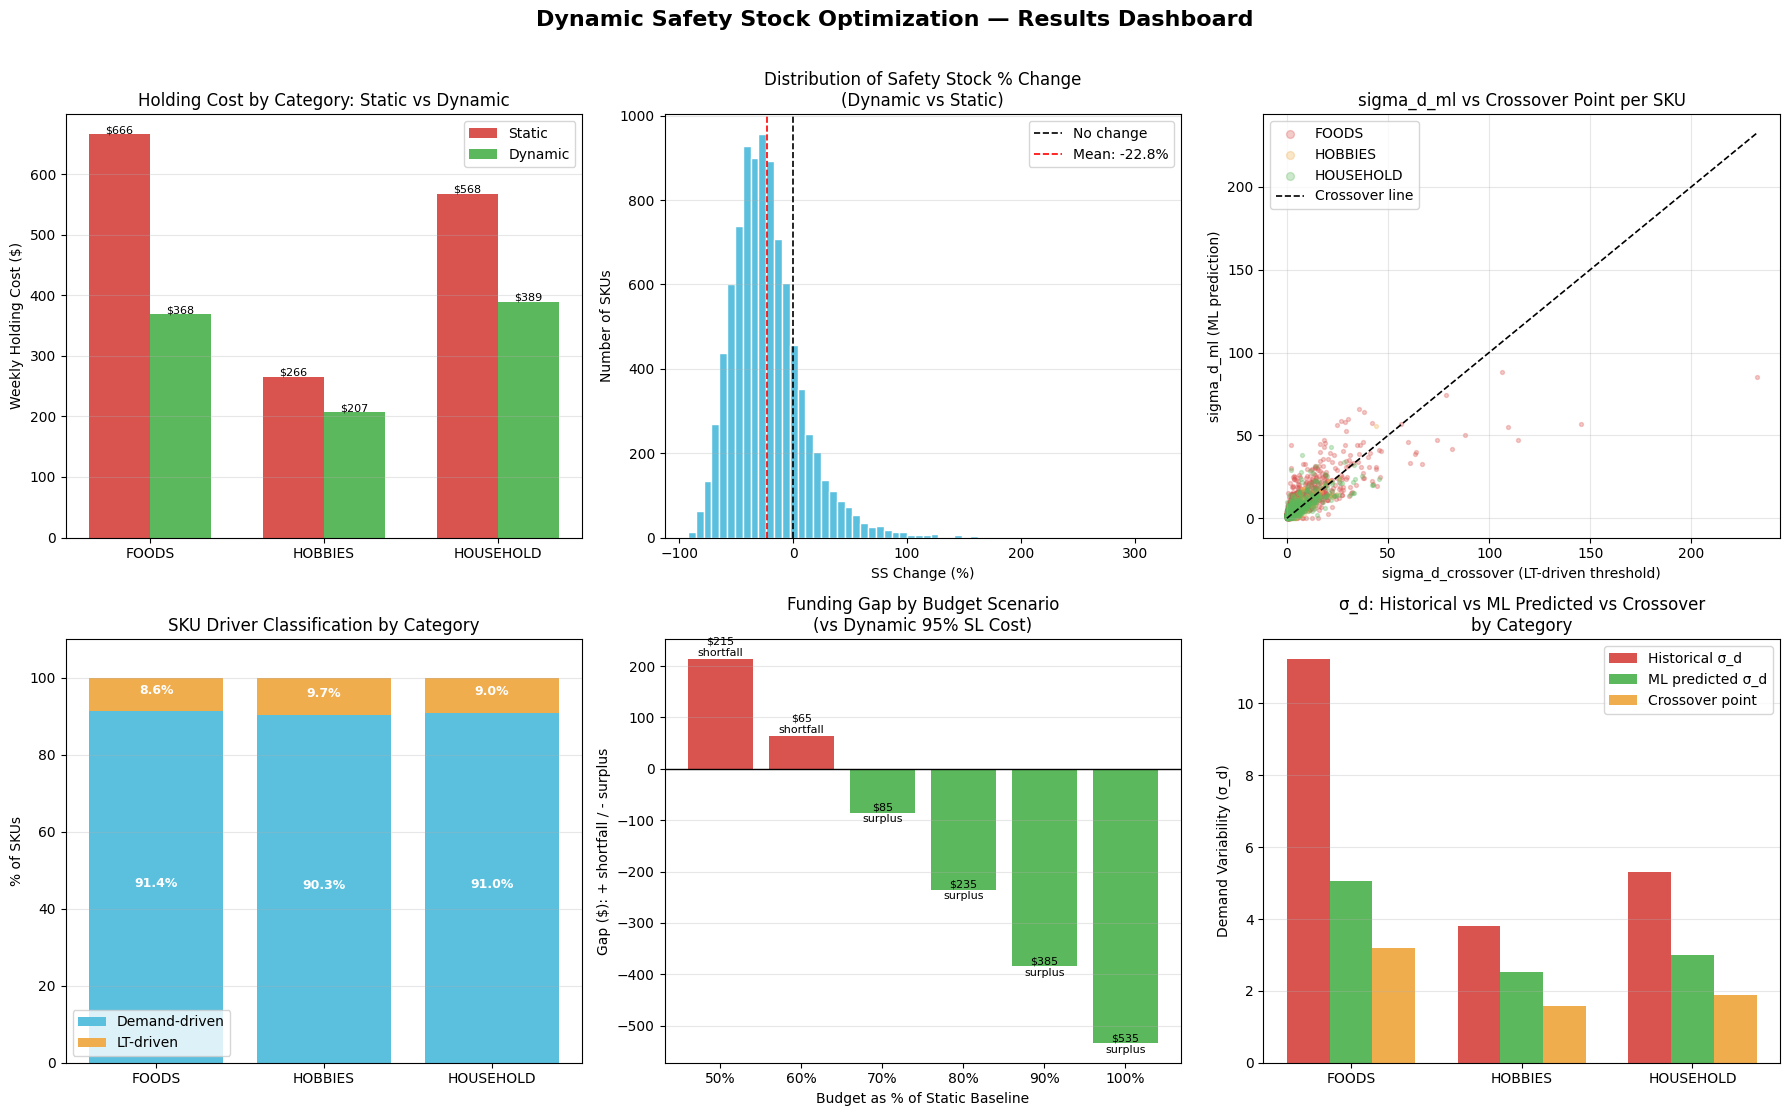

Dashboard saved.


In [333]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Dynamic Safety Stock Optimization — Results Dashboard',
             fontsize=16, fontweight='bold', y=1.01)

# ── Chart 1: Static vs Dynamic Holding Cost by Category ──────────────────────
ax1 = axes[0, 0]
cats      = cat_summary['cat_id'].tolist()
x         = np.arange(len(cats))
width     = 0.35

ax1.bar(x - width/2, cat_summary['static_total'],  width, label='Static',  color='#d9534f')
ax1.bar(x + width/2, cat_summary['dynamic_total'], width, label='Dynamic', color='#5cb85c')

for i, (s, d) in enumerate(zip(cat_summary['static_total'], cat_summary['dynamic_total'])):
    ax1.text(i - width/2, s + 2, f'${s:.0f}', ha='center', fontsize=8)
    ax1.text(i + width/2, d + 2, f'${d:.0f}', ha='center', fontsize=8)

ax1.set_xticks(x)
ax1.set_xticklabels(cats)
ax1.set_title('Holding Cost by Category: Static vs Dynamic')
ax1.set_ylabel('Weekly Holding Cost ($)')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# ── Chart 2: Histogram of SS % Change ────────────────────────────────────────
ax2 = axes[0, 1]
ax2.hist(sku_stats['ss_change_pct'], bins=60, color='#5bc0de', edgecolor='white')
ax2.axvline(0, color='black', linestyle='--', linewidth=1.2, label='No change')
ax2.axvline(sku_stats['ss_change_pct'].mean(), color='red',
            linestyle='--', linewidth=1.2,
            label=f"Mean: {sku_stats['ss_change_pct'].mean():.1f}%")
ax2.set_title('Distribution of Safety Stock % Change\n(Dynamic vs Static)')
ax2.set_xlabel('SS Change (%)')
ax2.set_ylabel('Number of SKUs')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# ── Chart 3: Scatter — sigma_d_ml vs Crossover Point ─────────────────────────
ax3 = axes[0, 2]
colors = {'FOODS': '#d9534f', 'HOBBIES': '#f0ad4e', 'HOUSEHOLD': '#5cb85c'}

for cat, grp in sku_stats.groupby('cat_id'):
    ax3.scatter(grp['sigma_d_crossover'], grp['sigma_d_ml'],
                alpha=0.3, s=8, label=cat, color=colors[cat])

max_val = max(sku_stats['sigma_d_crossover'].max(), sku_stats['sigma_d_ml'].max())
ax3.plot([0, max_val], [0, max_val], 'k--', linewidth=1.2, label='Crossover line')
ax3.set_title('sigma_d_ml vs Crossover Point per SKU')
ax3.set_xlabel('sigma_d_crossover (LT-driven threshold)')
ax3.set_ylabel('sigma_d_ml (ML prediction)')
ax3.legend(markerscale=2)
ax3.grid(alpha=0.3)

# ── Chart 4: Demand-driven vs LT-driven by Category ──────────────────────────
ax4 = axes[1, 0]
demand_pct = cat_crossover['demand_driven_pct'].values
lt_pct     = cat_crossover['lt_driven_pct'].values
cat_labels = cat_crossover.index.tolist()
x4         = np.arange(len(cat_labels))

ax4.bar(x4, demand_pct, label='Demand-driven', color='#5bc0de')
ax4.bar(x4, lt_pct,     bottom=demand_pct, label='LT-driven', color='#f0ad4e')

for i, (d, l) in enumerate(zip(demand_pct, lt_pct)):
    ax4.text(i, d/2,       f'{d:.1f}%', ha='center', fontsize=9, color='white', fontweight='bold')
    ax4.text(i, d + l/2,   f'{l:.1f}%', ha='center', fontsize=9, color='white', fontweight='bold')

ax4.set_xticks(x4)
ax4.set_xticklabels(cat_labels)
ax4.set_title('SKU Driver Classification by Category')
ax4.set_ylabel('% of SKUs')
ax4.set_ylim(0, 110)
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

# ── Chart 5: Funding Gap Scenario Analysis ────────────────────────────────────
ax5 = axes[1, 1]
factors  = [0.50, 0.60, 0.70, 0.80, 0.90, 1.00]
budgets  = [total_static_cost * f for f in factors]
gaps     = [total_dynamic_cost - b for b in budgets]
bar_colors = ['#d9534f' if g > 0 else '#5cb85c' for g in gaps]
labels   = [f'{int(f*100)}%' for f in factors]

bars = ax5.bar(labels, gaps, color=bar_colors)
ax5.axhline(0, color='black', linewidth=1.0)

for bar, gap in zip(bars, gaps):
    label = f'${abs(gap):.0f}\n{"shortfall" if gap > 0 else "surplus"}'
    ypos  = gap + 5 if gap > 0 else gap - 18
    ax5.text(bar.get_x() + bar.get_width()/2, ypos,
             label, ha='center', fontsize=8)

ax5.set_title('Funding Gap by Budget Scenario\n(vs Dynamic 95% SL Cost)')
ax5.set_xlabel('Budget as % of Static Baseline')
ax5.set_ylabel('Gap ($): + shortfall / - surplus')
ax5.grid(axis='y', alpha=0.3)

# ── Chart 6: sigma_d Comparison — Historical vs ML by Category ───────────────
ax6 = axes[1, 2]
x6    = np.arange(len(cat_means))
w     = 0.25

ax6.bar(x6 - w,   cat_means['avg_sigma_d_hist'],     w, label='Historical σ_d', color='#d9534f')
ax6.bar(x6,       cat_means['avg_sigma_d_ml'],       w, label='ML predicted σ_d', color='#5cb85c')
ax6.bar(x6 + w,   cat_means['avg_sigma_d_crossover'],w, label='Crossover point', color='#f0ad4e')

ax6.set_xticks(x6)
ax6.set_xticklabels(cat_means['cat_id'])
ax6.set_title('σ_d: Historical vs ML Predicted vs Crossover\nby Category')
ax6.set_ylabel('Demand Variability (σ_d)')
ax6.legend()
ax6.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('results_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved.")

In [343]:
print(sku_stats.columns.tolist())
print(sku_stats.shape)
print(sku_stats.isnull().sum().sum())

# Saving final version
sku_stats.to_parquet('sku_stats_final.parquet', index=False)
print("Saved.")

['item_id', 'store_id', 'cat_id', 'd_bar', 'sigma_d', 'L_bar', 'sigma_L', 'sell_price', 'static_ss', 'holding_cost', 'static_holding_cost', 'sigma_d_ml', 'dynamic_ss', 'dynamic_holding_cost', 'ss_change', 'ss_change_pct', 'holding_cost_change', 'sigma_d_crossover', 'driver']
(9147, 19)
0
Saved.


In [342]:
import pandas as pd

df = pd.read_parquet("sku_stats_final.parquet")

print(df.columns.tolist())
print(df.shape)
print(df[["static_holding_cost", "dynamic_holding_cost", "cat_id"]].head())

cat_summary = df.groupby("cat_id").agg(
    static_total  =("static_holding_cost",  "sum"),
    dynamic_total =("dynamic_holding_cost", "sum"),
).reset_index()

print(cat_summary)

['item_id', 'store_id', 'cat_id', 'd_bar', 'sigma_d', 'L_bar', 'sigma_L', 'sell_price', 'static_ss', 'holding_cost', 'static_holding_cost', 'sigma_d_ml', 'dynamic_ss', 'dynamic_holding_cost', 'ss_change', 'ss_change_pct', 'holding_cost_change', 'sigma_d_crossover', 'driver']
(9147, 19)
   static_holding_cost  dynamic_holding_cost cat_id
0             0.077873              0.056916  FOODS
1             0.039194              0.034737  FOODS
2             0.023551              0.015770  FOODS
3             0.101770              0.095111  FOODS
4             0.070004              0.064418  FOODS
      cat_id  static_total  dynamic_total
0      FOODS    665.607061     368.467699
1    HOBBIES    265.709729     206.837066
2  HOUSEHOLD    567.682479     388.920563
